In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [2]:
tsla = pd.read_csv("../data/processed/TSLA_cleaned.csv", index_col=0, parse_dates=True)

tsla.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [3]:
tsla.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

In [4]:
tsla_price = tsla["Adj Close"].dropna()

tsla_price.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: Adj Close, dtype: float64

In [5]:
train = tsla_price[:"2024-12-31"]
test = tsla_price["2025-01-01":]

print("Training data:", train.index.min(), "to", train.index.max())
print("Testing data:", test.index.min(), "to", test.index.max())
print("Train size:", len(train))
print("Test size:", len(test))

Training data: 2015-01-02 00:00:00 to 2024-12-31 00:00:00
Testing data: 2025-01-02 00:00:00 to 2026-06-30 00:00:00
Train size: 2516
Test size: 373


In [6]:
best_order = (5, 1, 0)

test_model = ARIMA(train, order=best_order)
test_model_fit = test_model.fit()

print(test_model_fit.summary())

/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 2516
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8180.940
Date:                Sun, 05 Jul 2026   AIC                          16373.881
Time:                        23:37:55   BIC                          16408.861
Sample:                             0   HQIC                         16386.576
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0050      0.012     -0.410      0.682      -0.029       0.019
ar.L2          0.0100      0.011      0.947      0.344      -0.011       0.031
ar.L3         -0.0092      0.013     -0.728      0.4

In [7]:
test_forecast_result = test_model_fit.get_forecast(steps=len(test))

test_predictions = test_forecast_result.predicted_mean
test_predictions.index = test.index

test_conf_int = test_forecast_result.conf_int()
test_conf_int.index = test.index

test_predictions.head()

/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Date
2025-01-02    403.247023
2025-01-03    402.563185
2025-01-06    402.491701
2025-01-07    402.207281
2025-01-08    402.380685
Name: predicted_mean, dtype: float64

In [8]:
final_model = ARIMA(tsla_price, order=best_order)
final_model_fit = final_model.fit()

print(final_model_fit.summary())

/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 2889
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -9842.674
Date:                Tue, 07 Jul 2026   AIC                          19697.348
Time:                        14:48:28   BIC                          19733.158
Sample:                             0   HQIC                         19710.254
                               - 2889                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0243      0.012     -1.983      0.047      -0.048      -0.000
ar.L2          0.0017      0.012      0.151      0.880      -0.021       0.024
ar.L3         -0.0111      0.012     -0.893      0.3

In [9]:
forecast_steps = 252

future_forecast_result = final_model_fit.get_forecast(steps=forecast_steps)

future_predictions = future_forecast_result.predicted_mean
future_conf_int = future_forecast_result.conf_int()

/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
future_dates = pd.bdate_range(
    start=tsla_price.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps
)

future_predictions.index = future_dates
future_conf_int.index = future_dates

In [11]:
import os

os.makedirs("../reports/figures", exist_ok=True)

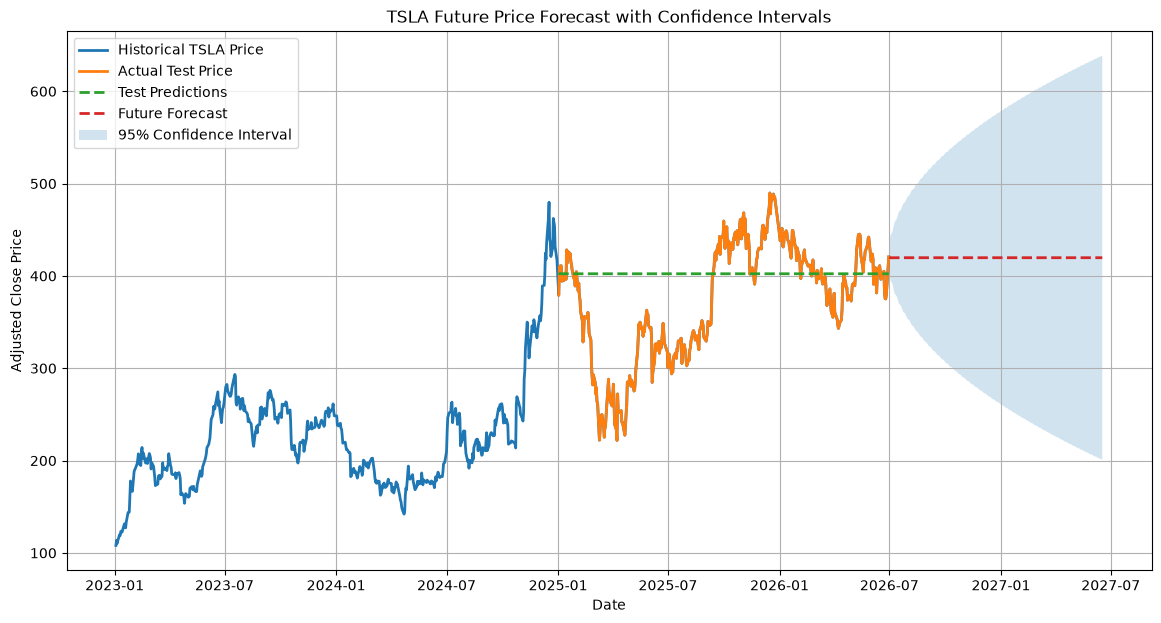

In [12]:
plt.figure(figsize=(14, 7))

# Show only recent history to keep the chart readable
recent_history = tsla_price["2023-01-01":]

plt.plot(recent_history.index, recent_history, label="Historical TSLA Price", linewidth=2)
plt.plot(test.index, test, label="Actual Test Price", linewidth=2)
plt.plot(test_predictions.index, test_predictions, label="Test Predictions", linestyle="--", linewidth=2)

plt.plot(future_predictions.index, future_predictions, label="Future Forecast", linestyle="--", linewidth=2)

plt.fill_between(
    future_conf_int.index,
    future_conf_int.iloc[:, 0],
    future_conf_int.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("TSLA Future Price Forecast with Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)

plt.savefig("../reports/figures/tsla_future_forecast_confidence_interval.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
forecast_df = pd.DataFrame({
    "Forecasted_TSLA_Price": future_predictions,
    "Lower_95_CI": future_conf_int.iloc[:, 0],
    "Upper_95_CI": future_conf_int.iloc[:, 1]
})

forecast_df.to_csv("../data/processed/tsla_future_forecast.csv")

forecast_df.head()

,Forecasted_TSLA_Price,Lower_95_CI,Upper_95_CI
2026-07-01,420.376815,406.050262,434.703368
2026-07-02,420.003660,399.987584,440.019736
2026-07-03,419.683476,395.250499,444.116452
2026-07-06,419.722168,391.636307,447.808028
2026-07-07,419.752670,388.481898,451.023442


In [14]:
last_actual_price = tsla_price.iloc[-1]
final_forecast_price = future_predictions.iloc[-1]

forecasted_return = (final_forecast_price - last_actual_price) / last_actual_price

print("Last actual TSLA price:", last_actual_price)
print("Final forecasted TSLA price:", final_forecast_price)
print("Forecasted 12-month return:", forecasted_return)

Last actual TSLA price: 420.6000061035156
Final forecasted TSLA price: 419.756911729403
Forecasted 12-month return: -0.002004503951208077


In [15]:
if forecasted_return > 0.05:
    print("Trend: Upward forecast")
elif forecasted_return < -0.05:
    print("Trend: Downward forecast")
else:
    print("Trend: Relatively stable forecast")

Trend: Relatively stable forecast


In [16]:
ci_width = future_conf_int.iloc[:, 1] - future_conf_int.iloc[:, 0]

first_30_days_width = ci_width.iloc[:30].mean()
last_30_days_width = ci_width.iloc[-30:].mean()

print("Average CI width in first 30 forecast days:", first_30_days_width)
print("Average CI width in last 30 forecast days:", last_30_days_width)
print("Change in uncertainty:", last_30_days_width - first_30_days_width)

Average CI width in first 30 forecast days: 103.660325865232
Average CI width in last 30 forecast days: 425.3200670934289
Change in uncertainty: 321.65974122819694


In [17]:
if last_30_days_width > first_30_days_width:
    print("Uncertainty increases over time.")
else:
    print("Uncertainty does not increase significantly.")

Uncertainty increases over time.


## Market Opportunities and Risks

The forecast provides a potential opportunity if the predicted TSLA price trend is upward. A positive forecast may suggest that TSLA could contribute strong returns to the portfolio. This is consistent with TSLA's historical annual return of approximately 45.59%.

However, TSLA also carries significant risk. Its annual volatility is approximately 57.17%, which is much higher than BND and SPY. The 95% Value at Risk is approximately -5.17%, meaning that on the worst 5% of trading days, TSLA may lose more than 5.17%. Therefore, even if the forecast shows upside potential, the investment decision should consider uncertainty and portfolio diversification.

The confidence interval also shows that uncertainty increases as the forecast horizon becomes longer. This means the 6-month forecast is more reliable than the 12-month forecast. For portfolio management, the forecast should be used as one input alongside risk metrics, diversification, and market judgment.